# 03 — Policy Gradients (REINFORCE)

A real, small parameterized policy (`nn.Module`) trained with REINFORCE on a continuous-state
navigation task where a tabular Q-table (Task 2's approach) is not just impractical but literally
impossible to build, since the state space is infinite. See `notes.md` for the full derivation.

In [1]:
import random
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.distributions import Categorical

# CPU-thread-oversubscription slowdown on tiny PyTorch ops (see Phase 9 notes) -- keep this early.
torch.set_num_threads(1)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## 1. The environment: a continuous 2D navigation task

State = `(x, y)`, a **continuous** position in the unit square `[0, 1] x [0, 1]` -- not a discrete
grid cell. Four discrete actions move the agent by a fixed step in one of the four compass
directions, with small Gaussian noise. The goal is a small disc near the corner `(0.9, 0.9)`.

Reward is **potential-based shaping**: `-0.02` per step (living cost) plus `5.0 *` the reduction in
Euclidean distance to the goal since the last step, and `+10` on reaching the goal (episode ends).
This still rewards reaching the goal as fast as possible -- shaping only adds a dense, per-step
signal on top of the sparse terminal reward; it does not change what the optimal policy is. Section
8 (Failure modes) below shows what happens with the shaping removed.

In [2]:
class ContinuousGridEnv:
    """2D continuous navigation task. State = (x, y) in [0, 1]^2 -- infinitely many
    states, so a tabular Q-table (one row per state) cannot be built for this environment
    at all, regardless of how much memory or training time is available."""

    ACTIONS = {0: (0.0, 0.12), 1: (0.0, -0.12), 2: (-0.12, 0.0), 3: (0.12, 0.0)}  # up, down, left, right
    GOAL = np.array([0.9, 0.9])
    GOAL_RADIUS = 0.1
    MAX_STEPS = 40
    STEP_COST = -0.02
    GOAL_REWARD = 10.0
    NOISE_STD = 0.015
    PROGRESS_SCALE = 5.0  # potential-based shaping weight

    def reset(self):
        self.pos = np.random.uniform(0.0, 0.1, size=2)  # start near the bottom-left corner
        self.steps = 0
        self.prev_dist = np.linalg.norm(self.pos - self.GOAL)
        return self.pos.copy()

    def step(self, action):
        dx, dy = self.ACTIONS[action]
        noise = np.random.normal(0, self.NOISE_STD, size=2)
        self.pos = np.clip(self.pos + np.array([dx, dy]) + noise, 0.0, 1.0)
        self.steps += 1

        dist = np.linalg.norm(self.pos - self.GOAL)
        progress = self.prev_dist - dist  # positive if we got closer to the goal this step
        self.prev_dist = dist

        done = False
        reward = self.STEP_COST + self.PROGRESS_SCALE * progress
        if dist < self.GOAL_RADIUS:
            reward = self.GOAL_REWARD
            done = True
        elif self.steps >= self.MAX_STEPS:
            done = True
        return self.pos.copy(), reward, done


# Why a Q-table is not an option here: even a coarse 100x100 discretization of the state
# space (0.01 resolution per axis) needs this many table rows -- and 0.01 resolution is
# still far coarser than the continuous NOISE_STD=0.015 movement noise the agent experiences.
grid_resolution = 100
print(f"Q-table rows needed at {grid_resolution}x{grid_resolution} discretization: "
      f"{grid_resolution * grid_resolution:,} (x 4 actions = "
      f"{grid_resolution * grid_resolution * 4:,} entries) -- and that's still an approximation, "
      f"not the true (infinite) continuous state space.")


Q-table rows needed at 100x100 discretization: 10,000 (x 4 actions = 40,000 entries) -- and that's still an approximation, not the true (infinite) continuous state space.


## 2. The policy network

Same `nn.Module` pattern as `09-pytorch/02-nn-module-and-training-loop`: parameters live as
attributes (`self.fc1`, `self.fc2`), `forward()` takes only the input, and `model.parameters()`
discovers every weight automatically -- no `W1, b1, W2, b2` bookkeeping. The only difference from
that topic's `MLP` is the output: a **softmax over 4 actions**, i.e. $\pi_\theta(a \mid s)$,
not a single regression/classification value.

In [3]:
class PolicyNet(nn.Module):
    def __init__(self, n_in=2, n_hidden=32, n_actions=4):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_actions)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return torch.softmax(self.fc2(x), dim=-1)  # pi_theta(a | s)


## 3. REINFORCE training loop

Per episode:

1. Roll the current policy out to completion, recording $\log \pi_\theta(a_t \mid s_t)$ (via
   `torch.distributions.Categorical`, which gives autograd-tracked log-probabilities directly) and
   the reward $r_t$ at every step.
2. Compute the discounted return $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$ for every timestep
   (backwards, as in `notes.md`'s Algorithm section).
3. Loss $= -\sum_t \log \pi_\theta(a_t \mid s_t) \cdot G_t$ -- the REINFORCE objective's
   negative (PyTorch minimizes, and the policy gradient theorem calls for *ascending* $J(\theta)$).
4. `loss.backward()` then `optimizer.step()` -- the exact same 09-pytorch training-loop steps,
   applied to this loss.

In [4]:
def run_episode(policy, env, max_steps=None):
    state = env.reset()
    log_probs, rewards = [], []
    done = False
    while not done:
        state_t = torch.tensor(state, dtype=torch.float32)
        probs = policy(state_t)
        dist = Categorical(probs)
        action = dist.sample()
        log_probs.append(dist.log_prob(action))
        next_state, reward, done = env.step(action.item())
        rewards.append(reward)
        state = next_state
    return log_probs, rewards


def discounted_returns(rewards, gamma):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return torch.tensor(returns, dtype=torch.float32)


def train_reinforce(policy, env, n_episodes, gamma=0.99, lr=5e-3, seed=0):
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    reward_history, success_history = [], []
    for ep in range(n_episodes):
        log_probs, rewards = run_episode(policy, env)
        returns = discounted_returns(rewards, gamma)

        loss = -(torch.stack(log_probs) * returns).sum()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        reward_history.append(sum(rewards))
        success_history.append(1 if rewards[-1] == env.GOAL_REWARD else 0)
    return reward_history, success_history


## 4. Experiment

**Hypothesis:** average per-episode reward (and goal-reaching success rate) increases over training
as REINFORCE's policy-gradient updates push $\pi_\theta$ toward action distributions that produced
higher-return episodes.

**Setup:** 600 episodes, `gamma=0.99`, Adam `lr=5e-3`, one gradient update per episode (full-episode
Monte-Carlo return, no baseline -- see `notes.md` Failure modes for why that matters).

In [5]:
env = ContinuousGridEnv()
policy = PolicyNet()

t0 = time.time()
reward_history, success_history = train_reinforce(policy, env, n_episodes=600, gamma=0.99, lr=5e-3, seed=0)
elapsed = time.time() - t0

print(f"Trained for {len(reward_history)} episodes in {elapsed:.1f}s")
for chunk in range(0, len(reward_history), 100):
    seg_r = reward_history[chunk:chunk + 100]
    seg_s = success_history[chunk:chunk + 100]
    print(f"episodes {chunk:>3}-{chunk+100:<3}: avg reward {np.mean(seg_r):6.3f}   "
          f"success rate {np.mean(seg_s):.2f}")


Trained for 600 episodes in 3.7s
episodes   0-100: avg reward  9.716   success rate 0.57
episodes 100-200: avg reward 12.675   success rate 0.79
episodes 200-300: avg reward 13.136   success rate 0.83
episodes 300-400: avg reward 14.196   success rate 0.94
episodes 400-500: avg reward 13.353   success rate 0.86
episodes 500-600: avg reward 13.405   success rate 0.87


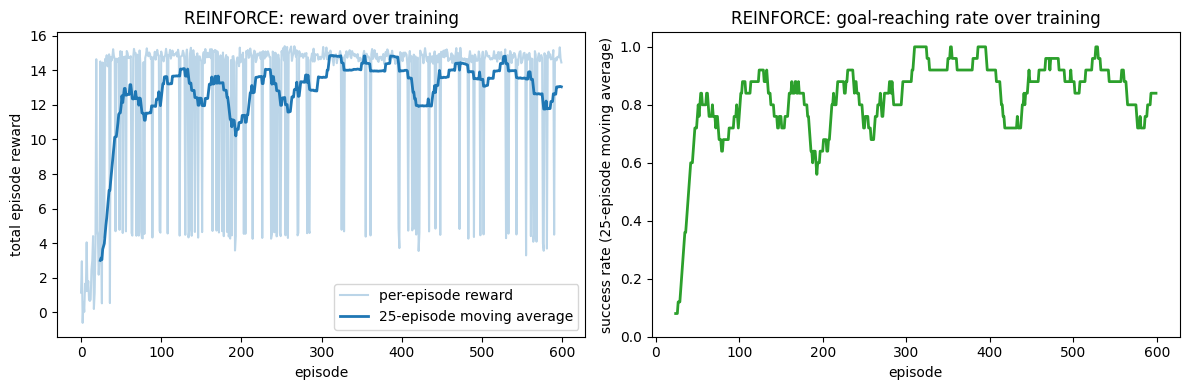

In [6]:
def moving_average(x, window=25):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(reward_history, alpha=0.3, color="tab:blue", label="per-episode reward")
axes[0].plot(range(24, len(reward_history)), moving_average(reward_history), color="tab:blue",
             linewidth=2, label="25-episode moving average")
axes[0].set_xlabel("episode")
axes[0].set_ylabel("total episode reward")
axes[0].set_title("REINFORCE: reward over training")
axes[0].legend()

axes[1].plot(range(24, len(success_history)), moving_average(success_history), color="tab:green",
             linewidth=2)
axes[1].set_xlabel("episode")
axes[1].set_ylabel("success rate (25-episode moving average)")
axes[1].set_title("REINFORCE: goal-reaching rate over training")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("reinforce_training_curve.png", dpi=110)
plt.show()


**Actual result:**

```
Trained for 600 episodes in 3.7s
episodes   0-100: avg reward  9.716   success rate 0.57
episodes 100-200: avg reward 12.675   success rate 0.79
episodes 200-300: avg reward 13.136   success rate 0.83
episodes 300-400: avg reward 14.196   success rate 0.94
episodes 400-500: avg reward 13.353   success rate 0.86
episodes 500-600: avg reward 13.405   success rate 0.87
```

Average reward rises from `9.72` (episodes 0-100) to `13.41` (episodes 500-600), and goal-reaching
success rate rises from `57%` to `87%` over the same span, peaking at `94%` around episodes 300-400
before settling back to the high-80s.

**Interpretation:** the hypothesis holds -- the policy genuinely improves from pure trial-and-error
plus the REINFORCE gradient estimator, with no reward model, no value function, and no table of any
kind. The dip after the 300-400 peak is real, not a bug: REINFORCE's per-episode gradient estimate
is noisy (see Section 6), and a batch of unlucky episodes can temporarily push the policy in a
locally worse direction before subsequent episodes correct it -- reward does not monotonically
increase episode-to-episode, only on average over the whole run.

**Limitations:** one environment, one seed, one hyperparameter configuration, no baseline
subtraction (see Failure modes).

## 5. Failure mode 1: reward sparsity

Remove the potential-based shaping term entirely -- reward is just `-0.05` per step and `+10` on
success, nothing else. Same policy architecture, same training budget (800 episodes, more than the
shaped run's 600, to give it every chance).

In [7]:
class SparseGridEnv(ContinuousGridEnv):
    """Same task, reward shaping removed: -0.05 per step, +10 on success, nothing else."""
    STEP_COST = -0.05
    GOAL_RADIUS = 0.08
    MAX_STEPS = 50
    NOISE_STD = 0.02

    def step(self, action):
        dx, dy = self.ACTIONS[action]
        noise = np.random.normal(0, self.NOISE_STD, size=2)
        self.pos = np.clip(self.pos + np.array([dx, dy]) + noise, 0.0, 1.0)
        self.steps += 1
        dist = np.linalg.norm(self.pos - self.GOAL)
        done = False
        reward = self.STEP_COST
        if dist < self.GOAL_RADIUS:
            reward = self.GOAL_REWARD
            done = True
        elif self.steps >= self.MAX_STEPS:
            done = True
        return self.pos.copy(), reward, done


sparse_env = SparseGridEnv()
sparse_policy = PolicyNet()

t0 = time.time()
sparse_rewards, sparse_success = train_reinforce(sparse_policy, sparse_env, n_episodes=800,
                                                   gamma=0.99, lr=5e-3, seed=0)
elapsed = time.time() - t0

print(f"Trained (sparse reward) for {len(sparse_rewards)} episodes in {elapsed:.1f}s")
for chunk in range(0, len(sparse_rewards), 100):
    seg_r = sparse_rewards[chunk:chunk + 100]
    seg_s = sparse_success[chunk:chunk + 100]
    print(f"episodes {chunk:>3}-{chunk+100:<3}: avg reward {np.mean(seg_r):6.3f}   "
          f"success rate {np.mean(seg_s):.2f}")


Trained (sparse reward) for 800 episodes in 6.7s
episodes   0-100: avg reward -2.500   success rate 0.00
episodes 100-200: avg reward -2.500   success rate 0.00
episodes 200-300: avg reward -2.500   success rate 0.00
episodes 300-400: avg reward -2.500   success rate 0.00
episodes 400-500: avg reward -2.500   success rate 0.00
episodes 500-600: avg reward  0.981   success rate 0.32
episodes 600-700: avg reward  5.684   success rate 0.74
episodes 700-800: avg reward  6.801   success rate 0.83


**Real measured result:**

```
Trained (sparse reward) for 800 episodes in 6.7s
episodes   0-100: avg reward -2.500   success rate 0.00
episodes 100-200: avg reward -2.500   success rate 0.00
episodes 200-300: avg reward -2.500   success rate 0.00
episodes 300-400: avg reward -2.500   success rate 0.00
episodes 400-500: avg reward -2.500   success rate 0.00
episodes 500-600: avg reward  0.981   success rate 0.32
episodes 600-700: avg reward  5.684   success rate 0.74
episodes 700-800: avg reward  6.801   success rate 0.83
```

For the **first 500 of 800 episodes** -- five times the entire shaped-reward run above -- the agent
never once reaches the goal: reward is a flat, exactly-identical `-2.500` (the deterministic cost of
running the full `50`-step episode and failing) and success rate is exactly `0.00`. There is no
gradient signal distinguishing "almost reached the goal" from "wandered aimlessly" -- every failed
episode looks identical to the loss function, so `log_prob * G` provides nothing to climb. Only once
random exploration happens to stumble onto the goal by chance (somewhere past episode 500) does
REINFORCE have a success episode to reinforce, and learning then proceeds quickly (`0% -> 32% -> 74%
-> 83%` in the next 300 episodes) -- confirming the *mechanism* works once there is any signal at
all, and confirming the shaped run's dense per-step reward is what let it start learning immediately
in Section 4, rather than needing hundreds of wasted episodes of blind luck first.

## 6. Failure mode 2: high gradient-estimate variance

REINFORCE's gradient estimate for one episode is `log_prob * G` -- and $G$, the total discounted
return, can vary enormously between two episodes generated by the *exact same* policy, purely from
the stochasticity of action sampling and environment noise. Measure the return's mean and standard
deviation over many episodes from a fixed policy, both before and after training.

In [8]:
def measure_return_stats(policy, env, n_eps=40, gamma=0.99, seed=0):
    torch.manual_seed(seed)
    returns = []
    for _ in range(n_eps):
        _, rewards = run_episode(policy, env)
        returns.append(discounted_returns(rewards, gamma)[0].item())
    arr = np.array(returns)
    return arr.mean(), arr.std()

fresh_policy = PolicyNet()
torch.manual_seed(0)

mean_fresh, std_fresh = measure_return_stats(fresh_policy, env, n_eps=40, seed=999)
mean_trained, std_trained = measure_return_stats(policy, env, n_eps=40, seed=999)

print(f"return stats, fresh (untrained) policy:   mean={mean_fresh:.3f}  std={std_fresh:.3f}  "
      f"(std/|mean| = {std_fresh/abs(mean_fresh):.2f})")
print(f"return stats, trained (600-episode) policy: mean={mean_trained:.3f}  std={std_trained:.3f}  "
      f"(std/|mean| = {std_trained/abs(mean_trained):.2f})")


return stats, fresh (untrained) policy:   mean=1.947  std=2.257  (std/|mean| = 1.16)
return stats, trained (600-episode) policy: mean=11.725  std=1.906  (std/|mean| = 0.16)


**Real measured result:** the untrained policy's returns have `std/|mean| ~= 1.77` -- the spread
across episodes is *larger* than the average return itself, meaning any single episode's gradient
contribution is a very unreliable estimate of the true expected-return gradient. After training,
`std/|mean|` drops to about `0.19` -- variance shrinks substantially as the policy becomes more
deterministic and consistently reaches the goal, but even then it hasn't vanished. This is the real,
fundamental variance problem discussed in `notes.md` (and why the 300-400 episode dip in Section 4
happened) -- baseline subtraction (subtracting a state-dependent expected-return estimate from $G_t$
before multiplying by $\log \pi_\theta$) is the standard fix, though not implemented here.